In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

In [ ]:
from GridMaze.analysis.distance_to_goal import distance_metrics as dm

reload(dm)
cpd_summary_df = dm.get_distance_metric_CPD_summary_df(verbose=True)  # need to reload
weights_summary_df = dm.get_weight_metrics_summary_df(verbose=True)

Loading CPD summaries df from /ceph/behrens/peter_doohan/goalNav_mFC/experiment/results/distance_to_goal/distance_metrics/cpd_summary_df.csv
Loading weight metric summaries df from /ceph/behrens/peter_doohan/goalNav_mFC/experiment/results/distance_to_goal/distance_metrics/weight_metric_summary_df.csv


Main figures (prelim)

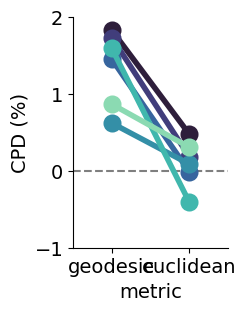

In [27]:
reload(dm)
f, ax = plt.subplots(1, 1, figsize=(2, 3))
dm.plot_cross_subject_CPD_comparison(
    cpd_summary_df, comparison="geodesic_vs_euclidean", maze_names=["maze_1", "maze_2"], late_sessions=True, ax=ax
)
f.savefig("../results/distance_to_goal/figures/cpd_comparison_geodesic_vs_euclidean.pdf")

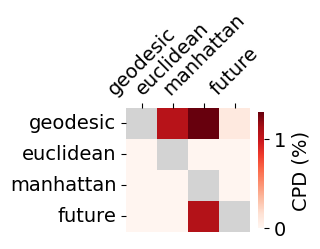

In [5]:
dm.plot_pairwise_CPD_summary(cpd_summary_df, late_sessions=True, maze_names=["maze_1", "maze_2"])

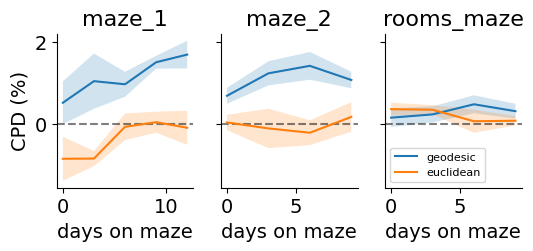

In [6]:
dm.plot_CPD_timeseries(cpd_summary_df, comparison="geodesic_vs_euclidean", group_days=3)

Supp figures (prelim)

geodesic_vs_euclidean: L1_ratio t-stat: -4.541, p-value: 6.162e-03


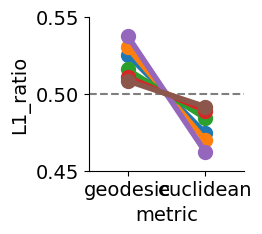

In [7]:
dm.plot_cross_subject_norm_comparison(
    weights_summary_df, comparison="geodesic_vs_euclidean", maze_names=["maze_1", "maze_2"], late_sessions=True
)

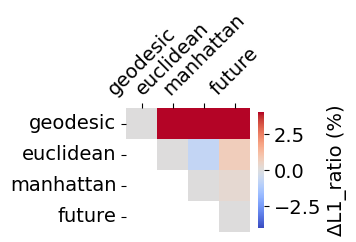

In [8]:
dm.plot_all_pairwise_metric_norm_diffs(
    weights_summary_df, norm_metric="L1_ratio", late_sessions=True, maze_names=["maze_1", "maze_2"]
)

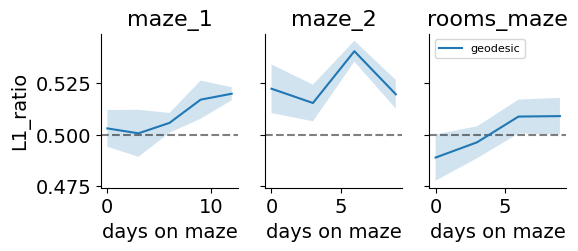

In [9]:
dm.plot_weights_comparison_timeseries(
    weights_summary_df, comparison="geodesic_vs_euclidean", plot_metric="geodesic", group_days=3
)

Characterising population tuning to distance to goal

In [20]:
from GridMaze.analysis.distance_to_goal import population_tuning as pt

In [21]:
fit_summary_df = pt.get_tuning_fits_summary_df()

clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


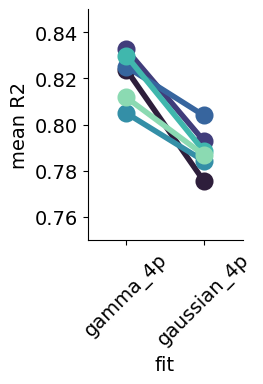

In [26]:
reload(pt)
f, ax = plt.subplots(1, 1, figsize=(2, 3))
pt.plot_cross_subject_curve_fit_comparison(fit_summary_df, curve_fits=["gamma_4p", "gaussian_4p"], ax=ax)
ax.set_ylim(0.75, 0.85)
f.savefig("../results/distance_to_goal/figures/gamma_vs_gaussian.pdf")

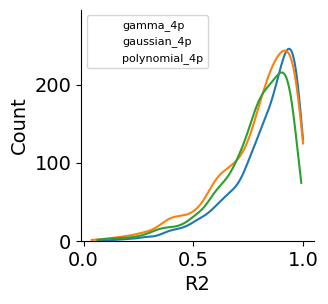

In [11]:
pt.plot_curve_fit_distributions(fit_summary_df)

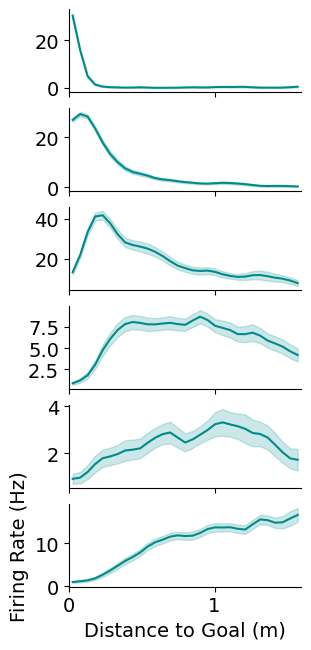

In [43]:
# plot some individual units

from GridMaze.analysis.cluster_tuning import distance_to_goal as dtg

reload(dtg)
from GridMaze.analysis.core import get_clusters as gc

reload(gc)

example_clusters = [
    "m2.2022-07-03.maze_cluster43",
    "m3.2022-07-02.maze_cluster44",
    "m2.2022-07-03.maze_cluster9",
    "m3.2022-07-01.maze_cluster38",
    "m6.2022-07-02.maze_cluster40",
    # "m6.2022-07-02.maze_cluster40",
    "m3.2022-07-16.maze_cluster137",
    # "m2.2022-07-03.maze_cluster49",
]

f_units_pos, axes = plt.subplots(6, 1, figsize=(3, 7.5), sharex=True)

for cluster, ax in zip(example_clusters, axes.flatten()):
    Cluster = gc.get_cluster(cluster)
    Cluster.plot_tuning(feature="distance_to_goal", ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes[-1].set_xlabel("Distance to Goal (m)")
axes[-1].set_ylabel("Firing Rate (Hz)")

f_units_pos.savefig("../results/distance_to_goal/figures/example_units_pos.pdf")

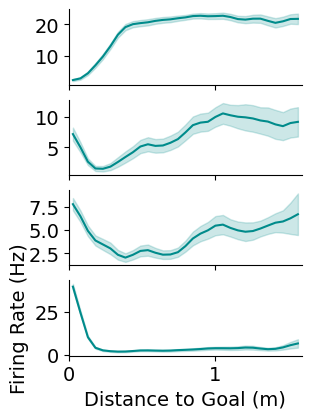

In [44]:
example_clusters = [
    "m7.2022-07-03.maze_cluster54",
    "m2.2022-07-13.maze_cluster99",
    "m3.2022-07-24.maze_cluster16",
    "m7.2022-07-11.maze_cluster28",
]

f_units_neg, axes = plt.subplots(4, 1, figsize=(3, 4.5), sharex=True)

for cluster, ax in zip(example_clusters, axes.flatten()):
    Cluster = gc.get_cluster(cluster)
    Cluster.plot_tuning(feature="distance_to_goal", ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes[-1].set_xlabel("Distance to Goal (m)")
axes[-1].set_ylabel("Firing Rate (Hz)")

f_units_neg.savefig("../results/distance_to_goal/figures/example_units_neg.pdf")

In [12]:
# get data to plot distance tuning heatmaps
population_tuning_df = pt.get_population_tuning_df()

frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


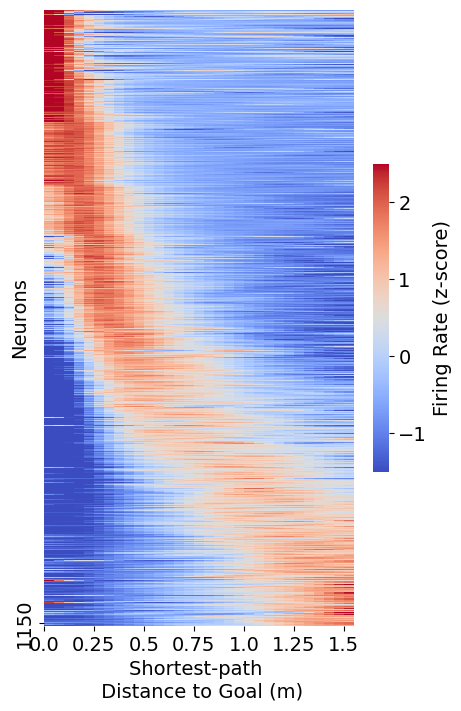

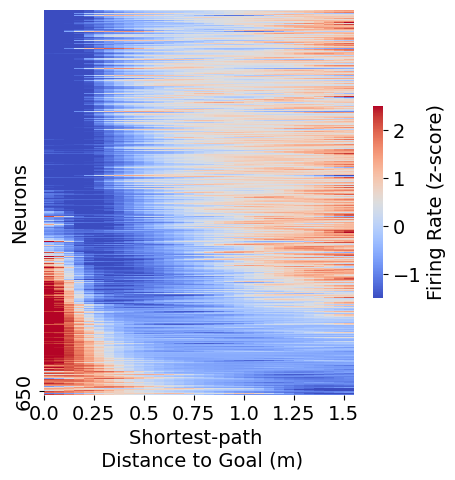

In [42]:
f_hm_pos, ax1 = plt.subplots(1, 1, figsize=(5, 8))
reload(pt)
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="pos", ax=ax1, cmap="coolwarm", v_range=(-1.5, 2.5))
f_hm_pos.savefig("../results/distance_to_goal/figures/distance_tuning_heatmap_pos.pdf")

f_hm_neg, ax2 = plt.subplots(1, 1, figsize=(5, 5))
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="neg", ax=ax2, cmap="coolwarm", v_range=(-1.5, 2.5))
f_hm_neg.savefig("../results/distance_to_goal/figures/distance_tuning_heatmap_neg.pdf")

In [ ]:
# plot distance results together

In [17]:
# no clear anatomical organisation of distance tunned neurons across the medial wall
reload(pt)
sign = "pos"  # or "neg"
population_anatomy_df = pt.get_population_anatomy_df(sign=sign)

frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


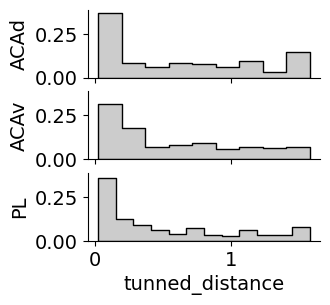

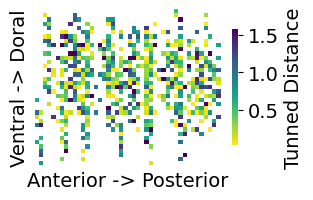

In [18]:
pt.plot_region_distance_tuning_distributions(population_anatomy_df)
pt.plot_voxel_distance_tuning_heatmap(population_anatomy_df)

## Unit Match

In [ ]:
import numpy as np
from GridMaze.analysis.unit_match import get_across_maze_matches as mm
from GridMaze.analysis.unit_match import distance_to_goal as um_dtg

In [8]:
# get matches like this
matched_clusters = mm.get_cross_maze_matches(
    subject_ID="m2",
    maze_pair=("maze_1", "maze_2"),
    single_units=True,
    tuning_metric="distance_to_goal",
    min_split_half_corr=0.3,
    return_as="cluster_objects",
    verbose=True,
)
matched_clusters = np.array(matched_clusters)

Found 260 matches for m2, maze_1.maze_2, with the given criteria.


In [ ]:
select_clusters = matched_clusters[
    [250, 15, 77, 73, 248, 234, 230, 228, 209, 204, 247, 216, 212, 156, 242, 214, 152, 130, 227, 219, 217, 201, 158]
]

fav_clusters = select_clusters[[2, 0, 1, 16, 12, 18]]

fav_clusters = fav_clusters[[4, 0, 5, 3, 1, 2]]

In [16]:
fav_clusters

array([[-MazeCluster- Unique ID: m2.2022-07-05.maze_cluster64,
        -MazeCluster- Unique ID: m2.2022-07-11.maze_cluster49],
       [-MazeCluster- Unique ID: m2.2022-07-03.maze_cluster90,
        -MazeCluster- Unique ID: m2.2022-07-11.maze_cluster94],
       [-MazeCluster- Unique ID: m2.2022-07-05.maze_cluster28,
        -MazeCluster- Unique ID: m2.2022-07-11.maze_cluster26],
       [-MazeCluster- Unique ID: m2.2022-07-04.maze_cluster86,
        -MazeCluster- Unique ID: m2.2022-07-12.maze_cluster84],
       [-MazeCluster- Unique ID: m2.2022-07-05.maze_cluster44,
        -MazeCluster- Unique ID: m2.2022-07-13.maze_cluster65],
       [-MazeCluster- Unique ID: m2.2022-07-02.maze_cluster87,
        -MazeCluster- Unique ID: m2.2022-07-09.maze_cluster91]],
      dtype=object)

In [ ]:
fav_clusters = np.array(
    [
        ["m2.2022-07-05.maze_cluster64", "m2.2022-07-11.maze_cluster49"],
        ["m2.2022-07-03.maze_cluster90", "m2.2022-07-11.maze_cluster94"],
        ["m2.2022-07-05.maze_cluster28", "m2.2022-07-11.maze_cluster26"],
        ["m2.2022-07-04.maze_cluster86", "m2.2022-07-12.maze_cluster84"],
        ["m2.2022-07-05.maze_cluster44", "m2.2022-07-13.maze_cluster65"],
        ["m2.2022-07-02.maze_cluster87", "m2.2022-07-09.maze_cluster91"],
    ]
)

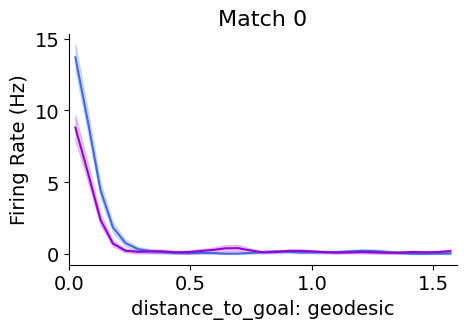

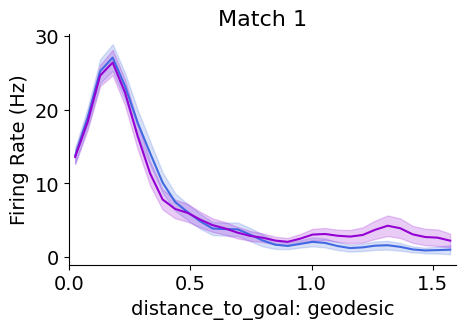

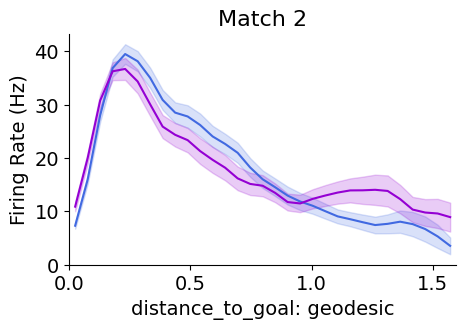

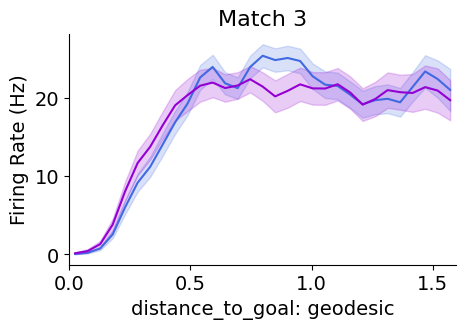

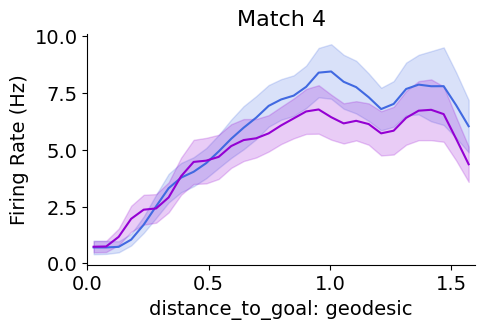

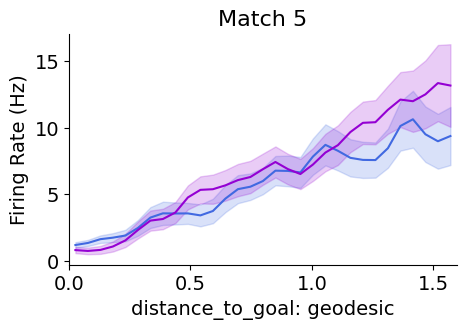

In [15]:
colors = ["royalblue", "darkviolet"]
for i, pair in enumerate(fav_clusters):
    f, ax = plt.subplots(1, 1, figsize=(5, 3))
    ax.spines[["top", "right"]].set_visible(False)
    for Clust, color in zip(pair, colors):
        Clust.plot_tuning(
            feature="distance_to_goal",
            ax=ax,
            feature_kwargs={"color": color},
        )
    ax.set_title(f"Match {i}")
    plt.show()